<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="350px" align="right" border="0"><br>

# Object Oriented Programming

**_Vectorized & Event-Based Backtesting_**

Dr. Yves J. Hilpisch | The Python Quants GmbH

<img src="http://hilpisch.com/images/tpq_bootcamp.png" width=350px align=left>

In [ ]:
!git clone https://github.com/tpq-classes/python_for_algo_trading_addon.git
import sys
sys.path.append('python_for_algo_trading_addon')


In [1]:
import math
import numpy as np
import pandas as pd
from pylab import plt
plt.style.use('seaborn-v0_8')
%matplotlib inline

## Interactive Vectorized Backtesting

### The Data

In [2]:
raw = pd.read_csv('http://hilpisch.com/tr_eikon_eod_data.csv',
                 index_col=0, parse_dates=True)

In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2216 entries, 2010-01-01 to 2018-06-29
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2138 non-null   float64
 1   MSFT.O  2138 non-null   float64
 2   INTC.O  2138 non-null   float64
 3   AMZN.O  2138 non-null   float64
 4   GS.N    2138 non-null   float64
 5   SPY     2138 non-null   float64
 6   .SPX    2138 non-null   float64
 7   .VIX    2138 non-null   float64
 8   EUR=    2216 non-null   float64
 9   XAU=    2211 non-null   float64
 10  GDX     2138 non-null   float64
 11  GLD     2138 non-null   float64
dtypes: float64(12)
memory usage: 225.1 KB


In [4]:
raw.head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4323,1096.35,NaN,NaN
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.00,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.65,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.50,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.90,49.10,110.82


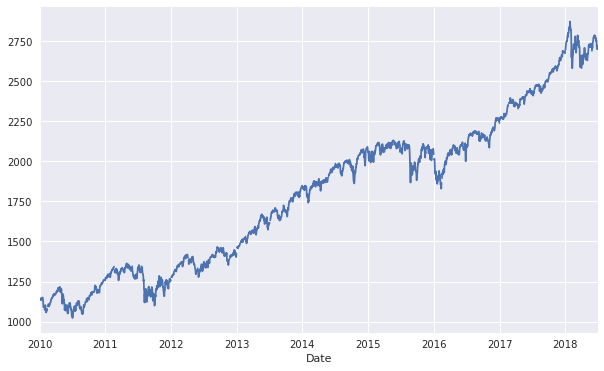

In [5]:
raw['.SPX'].plot(figsize=(10, 6));

In [6]:
data = pd.DataFrame(raw['AAPL.O'])

In [7]:
data.columns = ['Prices']

In [8]:
data = data.dropna()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Prices  2138 non-null   float64
dtypes: float64(1)
memory usage: 33.4 KB


### Deriving Statistics (SMAs)

In [10]:
data['SMA1'] = data['Prices'].rolling(42).mean()

In [11]:
data['SMA2'] = data['Prices'].rolling(252).mean()

In [12]:
data.head()

,Prices,SMA1,SMA2
Date,,,
2010-01-04,30.572827,NaN,NaN
2010-01-05,30.625684,NaN,NaN
2010-01-06,30.138541,NaN,NaN
2010-01-07,30.082827,NaN,NaN
2010-01-08,30.282827,NaN,NaN


In [13]:
data.tail()

,Prices,SMA1,SMA2
Date,,,
2018-06-25,182.17,185.606190,168.265556
2018-06-26,184.43,186.087381,168.418770
2018-06-27,184.16,186.607381,168.579206
2018-06-28,185.50,187.089286,168.736627
2018-06-29,185.11,187.470476,168.901032


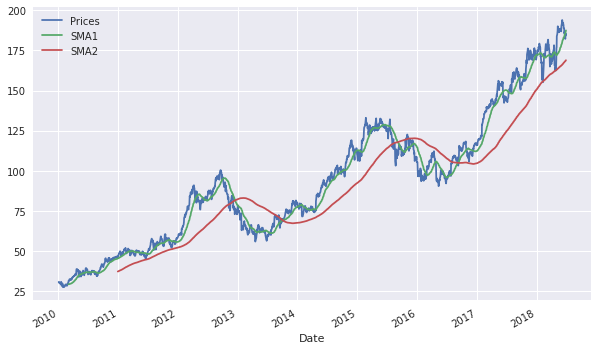

In [14]:
data.plot(figsize=(10, 6));

### Deriving Positions

In [15]:
data.dropna(inplace=True)

In [16]:
data['Positions'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)

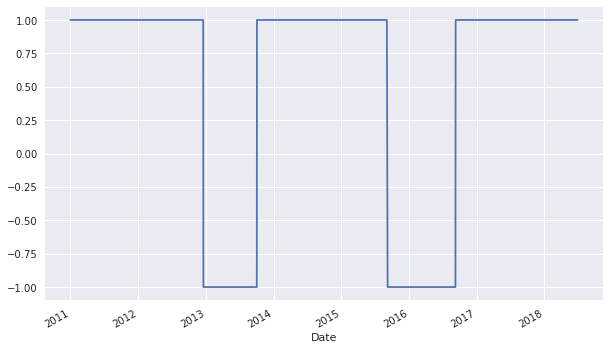

In [17]:
data['Positions'].plot(figsize=(10, 6));

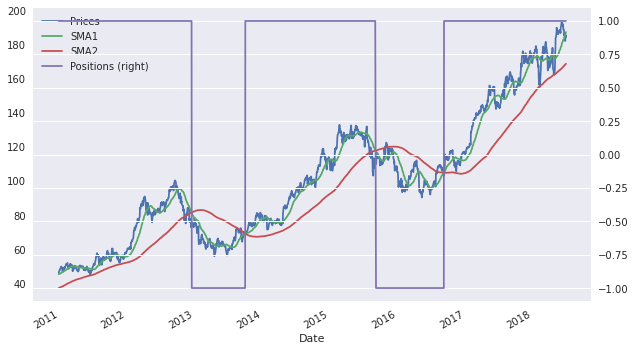

In [18]:
data.plot(figsize=(10, 6), secondary_y='Positions');

### Calculating Log Returns

In [19]:
data['Returns'] = np.log(data['Prices'] / data['Prices'].shift(1))

In [20]:
data.head()

,Prices,SMA1,SMA2,Positions,Returns
Date,,,,,
2010-12-31,46.079954,45.280967,37.120735,1,NaN
2011-01-03,47.081381,45.349708,37.186246,1,0.021500
2011-01-04,47.327096,45.412599,37.252521,1,0.005205
2011-01-05,47.714238,45.466102,37.322266,1,0.008147
2011-01-06,47.675667,45.522565,37.392079,1,-0.000809


### Benchmarking the Strategy

In [21]:
data['Strategy'] = data['Positions'].shift(1) * data['Returns']

In [22]:
data.head()

,Prices,SMA1,SMA2,Positions,Returns,Strategy
Date,,,,,,
2010-12-31,46.079954,45.280967,37.120735,1,NaN,NaN
2011-01-03,47.081381,45.349708,37.186246,1,0.021500,0.021500
2011-01-04,47.327096,45.412599,37.252521,1,0.005205,0.005205
2011-01-05,47.714238,45.466102,37.322266,1,0.008147,0.008147
2011-01-06,47.675667,45.522565,37.392079,1,-0.000809,-0.000809


In [23]:
data.dropna(inplace=True)

In [24]:
data[['Returns', 'Strategy']].sum()

Returns     1.390572
Strategy    1.759804
dtype: float64

In [25]:
np.exp(data[['Returns', 'Strategy']].sum())  # gross return for every USD invested

Returns     4.017148
Strategy    5.811299
dtype: float64

In [26]:
np.exp(data[['Returns', 'Strategy']].sum()) - 1  # net return for every USD invested

Returns     3.017148
Strategy    4.811299
dtype: float64

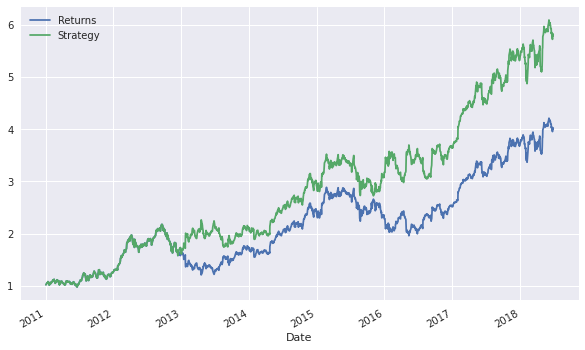

In [27]:
data[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6));

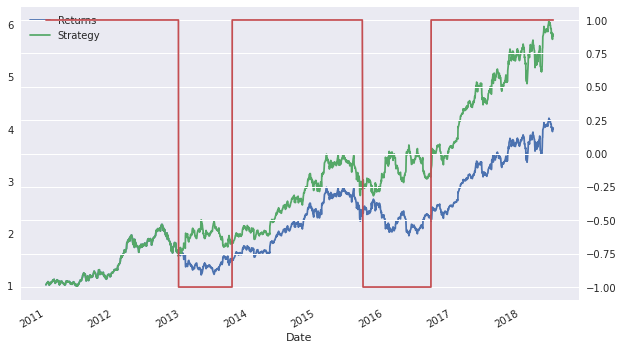

In [28]:
ax = data[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6))
data['Positions'].plot(ax=ax, secondary_y='Positions');

## Vectorized Backtesting via Classes

### Financial Data Base Class

In [29]:
class FinancialData(object):
    def __init__(self, symbol):
        self.symbol = symbol
        self.retrieve_data()
        
    def retrieve_data(self):
        self.raw = pd.read_csv('http://hilpisch.com/tr_eikon_eod_data.csv',
                                 index_col=0, parse_dates=True)
        self.data = pd.DataFrame(self.raw[self.symbol])
        self.data['Returns'] = np.log(self.data / self.data.shift(1))
        self.data.dropna(inplace=True)
        
    def plot_data(self, cols=None):
        if cols is None:
            cols = [self.symbol]
        self.data[cols].plot(figsize=(10, 6), title=self.symbol)

In [30]:
fd = FinancialData('AAPL.O')

In [31]:
fd.symbol

'AAPL.O'

In [32]:
fd.data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2061 entries, 2010-01-05 to 2018-06-29
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AAPL.O   2061 non-null   float64
 1   Returns  2061 non-null   float64
dtypes: float64(2)
memory usage: 48.3 KB


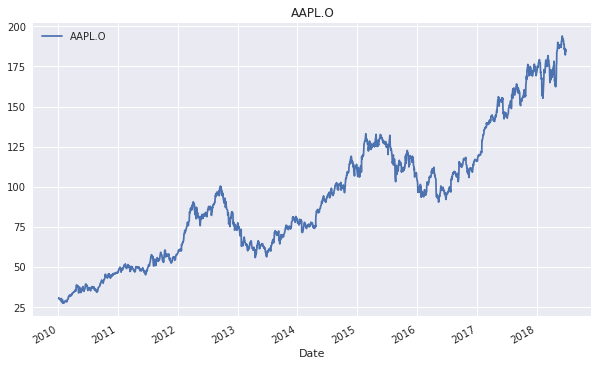

In [33]:
fd.plot_data()

### SMA Backtester Class

In [34]:
class SMABacktester(FinancialData):
    def __init__(self, symbol, SMA1, SMA2):
        super(SMABacktester, self).__init__(symbol)
        self.SMA1 = SMA1
        self.SMA2 = SMA2
        self.prepare_statistics()
        
    def prepare_statistics(self):
        self.data['SMA1'] = self.data[self.symbol].rolling(self.SMA1).mean()
        self.data['SMA2'] = self.data[self.symbol].rolling(self.SMA2).mean()
        self.data.dropna(inplace=True)
        
    def run_strategy(self):
        self.data['Positions'] = np.where(self.data['SMA1'] > self.data['SMA2'], 1, -1)
        self.data['Strategy'] = self.data['Positions'].shift(1) * self.data['Returns']
        self.data.dropna(inplace=True)
        self.results = self.data[['Returns', 'Strategy']].cumsum().apply(np.exp)
        return self.data[['Returns', 'Strategy']].sum().apply(np.exp)
    
    def plot_results(self):
        try:
            self.results
        except:
            self.run_strategy()
        self.results.plot(figsize=(10, 6))

In [35]:
sma = SMABacktester('AAPL.O', 42, 252)

In [36]:
sma.data.head()

,AAPL.O,Returns,SMA1,SMA2
Date,,,,
2011-01-13,49.382808,0.003652,45.921017,37.551719
2011-01-14,49.782807,0.008067,46.029265,37.627739
2011-01-19,48.405666,-0.005328,46.134061,37.700228
2011-01-20,47.525667,-0.018347,46.221289,37.769445
2011-01-21,46.674239,-0.018078,46.306765,37.834490


In [37]:
sma.data.tail()

,AAPL.O,Returns,SMA1,SMA2
Date,,,,
2018-06-25,182.17,-0.014983,185.028810,167.395913
2018-06-26,184.43,0.012330,185.523571,167.546071
2018-06-27,184.16,-0.001465,185.998333,167.700833
2018-06-28,185.50,0.007250,186.550238,167.864365
2018-06-29,185.11,-0.002105,187.022857,168.034365


In [38]:
sma.run_strategy()

Returns     2.994958
Strategy    3.525477
dtype: float64

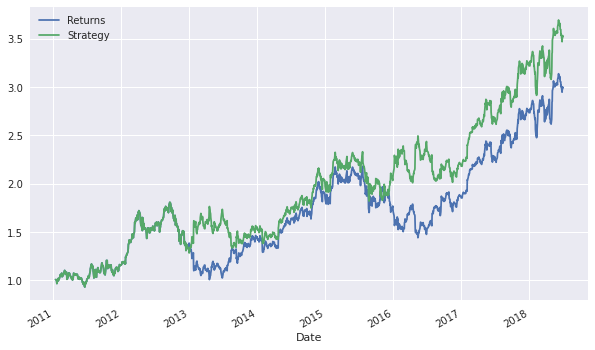

In [39]:
sma.plot_results()

### Multiple Backtests

In [40]:
sma = SMABacktester('AAPL.O', 42, 252)

In [41]:
sma.run_strategy()

Returns     2.994958
Strategy    3.525477
dtype: float64

In [42]:
sma = SMABacktester('AAPL.O', 42, 200)

In [43]:
sma.run_strategy()

Returns     3.341780
Strategy    3.801365
dtype: float64

In [44]:
sma = SMABacktester('AAPL.O', 30, 200)

In [45]:
sma.run_strategy()

Returns     3.341780
Strategy    4.843074
dtype: float64

### Some Improvements

In [46]:
class SMABacktester(FinancialData):
    def __init__(self, symbol, SMA1, SMA2):
        super(SMABacktester, self).__init__(symbol)
        self.SMA1 = SMA1
        self.SMA2 = SMA2
        self.prepare_statistics()
        
    def prepare_statistics(self):
        self.data['SMA1'] = self.data[self.symbol].rolling(self.SMA1).mean()
        self.data['SMA2'] = self.data[self.symbol].rolling(self.SMA2).mean()
        
    def run_strategy(self, SMA=None):
        if SMA is not None:
            self.SMA1 = SMA[0]
            self.SMA2 = SMA[1]
            self.prepare_statistics()
        self.results = self.data.copy()
        self.results.dropna(inplace=True)
        self.results['Positions'] = np.where(self.results['SMA1'] > self.results['SMA2'], 1, -1)
        self.results['Strategy'] = self.results['Positions'].shift(1) * self.results['Returns']
        self.results.dropna(inplace=True)
        return self.results[['Returns', 'Strategy']].sum().apply(np.exp)
    
    def plot_results(self):
        try:
            self.results
        except:
            self.run_strategy()
        self.results[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6))

In [47]:
sma = SMABacktester('AAPL.O', 42, 252)

In [48]:
sma.run_strategy()

Returns     2.994958
Strategy    3.525477
dtype: float64

In [49]:
sma.run_strategy((42, 200))

Returns     3.341780
Strategy    3.801365
dtype: float64

In [50]:
sma.run_strategy((30, 200))

Returns     3.341780
Strategy    4.843074
dtype: float64

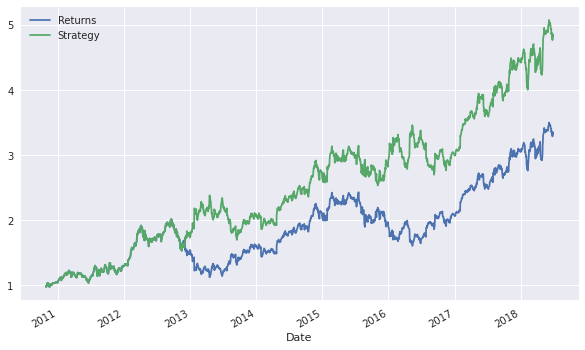

In [51]:
sma.plot_results()

### Doing Some "Optimization"

In [52]:
from itertools import product

In [53]:
list(product([30, 40, 50], [180, 200, 220, 240]))

[(30, 180),
 (30, 200),
 (30, 220),
 (30, 240),
 (40, 180),
 (40, 200),
 (40, 220),
 (40, 240),
 (50, 180),
 (50, 200),
 (50, 220),
 (50, 240)]

In [54]:
%%time
for SMA in product([30, 40, 50, 55, 60], [180, 200, 220, 240]):
    print(SMA, sma.run_strategy(SMA).values)

(30, 180) [3.57970563 4.59862263]
(30, 200) [3.34177958 4.84307426]
(30, 220) [3.267841   3.84531777]
(30, 240) [3.18092985 4.1441403 ]
(40, 180) [3.57970563 5.36399726]
(40, 200) [3.34177958 4.03454124]
(40, 220) [3.267841   4.79113005]
(40, 240) [3.18092985 3.85782844]
(50, 180) [3.57970563 3.70606983]
(50, 200) [3.34177958 5.44816145]
(50, 220) [3.267841   3.62970898]
(50, 240) [3.18092985 3.43818215]
(55, 180) [3.57970563 4.97957202]
(55, 200) [3.34177958 4.33921196]
(55, 220) [3.267841   3.48559204]
(55, 240) [3.18092985 3.37528295]
(60, 180) [3.57970563 5.14506127]
(60, 200) [3.34177958 3.77370321]
(60, 220) [3.267841   3.62485569]
(60, 240) [3.18092985 3.28957038]
CPU times: user 219 ms, sys: 3.93 ms, total: 223 ms
Wall time: 219 ms


## Exercises

Implement the following **improvements**:

* inclusion of **transaction costs** (fixed/variable)
* choice of **variable** start and end dates
* **optimization** of trading parameters
* in-sample vs. **out-of-sample** backtesting

## Event-based Backtesting

### Simulating "Events"

In [55]:
import time

In [56]:
for t in range(10):
    print(t, data.index[t], data.Prices.iloc[t])
    time.sleep(0.5)

0 2011-01-03 00:00:00 47.08138149000001
1 2011-01-04 00:00:00 47.32709553000001
2 2011-01-05 00:00:00 47.714238
3 2011-01-06 00:00:00 47.67566661000001
4 2011-01-07 00:00:00 48.01709484000001
5 2011-01-10 00:00:00 48.922093935
6 2011-01-11 00:00:00 48.80566548
7 2011-01-12 00:00:00 49.20280794000001
8 2011-01-13 00:00:00 49.38280776000001
9 2011-01-14 00:00:00 49.78280736000001


### Base Class

In [57]:
import math

In [58]:
math.floor(1000 / 45.5)

21

In [59]:
class BacktestingBase(FinancialData):
    def __init__(self, symbol, amount):
        super(BacktestingBase, self).__init__(symbol)
        self.amount = amount  # cash balance
        self.initial_amount = amount  # initial cash position
        self.position = 0  # initial position is neutral
        self.trades = 0  # number of trades
        self.units = 0  # number of units of the instrument traded
        
    def get_date_price(self, bar):
        return str(self.data.index[bar])[:10], self.data[self.symbol].iloc[bar]
    
    def print_current_balance(self, bar):
        date, price = self.get_date_price(bar)
        print('%s | current cash balance is   %8.2f' % (date, self.amount))
        
    def place_buy_order(self, bar, units=None, amount=None):
        date, price = self.get_date_price(bar)
        if amount is not None:
            units = math.floor(amount / price)
        self.units += units
        self.amount -= units * price
        self.trades += 1
        print('%s | buying  %d units at price %8.2f' % (date, units, price))
        self.print_current_balance(bar)
        
    def place_sell_order(self, bar, units=None, amount=None):
        date, price = self.get_date_price(bar)
        if amount is not None:
            units = math.floor(amount / price)
        self.units -= units
        self.amount += units * price
        self.trades += 1
        print('%s | selling %d units at price %8.2f' % (date, units, price))
        self.print_current_balance(bar)
        
    def close_out(self, bar):
        date, price = self.get_date_price(bar)
        self.amount += self.units * price
        self.trades += 1
        print(50 * '=')
        print('%s | closing out the position' % date)
        self.print_current_balance(bar)
        perf = (self.amount / self.initial_amount - 1) * 100
        print('%s | net return of strategy is %7.2f%%' % (date, perf))

In [60]:
bb = BacktestingBase('AAPL.O', 10000)

In [61]:
bb.get_date_price(10)

('2010-01-21', 29.724541704000007)

In [62]:
bb.units, bb.trades, bb.position

(0, 0, 0)

In [63]:
bb.place_buy_order(10, units=10)

2010-01-21 | buying  10 units at price    29.72
2010-01-21 | current cash balance is    9702.75


In [64]:
bb.place_buy_order(15, units=20)

2010-01-28 | buying  20 units at price    28.47
2010-01-28 | current cash balance is    9133.36


In [65]:
bb.units, bb.trades, bb.position

(30, 2, 0)

In [66]:
bb.place_sell_order(20, units=15)

2010-02-04 | selling 15 units at price    27.44
2010-02-04 | current cash balance is    9544.89


In [67]:
bb.units, bb.trades, bb.position

(15, 3, 0)

### Event-based SMA Backtester

In [68]:
class BacktestingSMAStrategy(BacktestingBase):
    def __init__(self, symbol, amount, SMA1, SMA2):
        super(BacktestingSMAStrategy, self).__init__(symbol, amount)
        self.SMA1 = SMA1
        self.SMA2 = SMA2
        self.prepare_statistics()
        
    def prepare_statistics(self):
        self.data['SMA1'] = self.data[self.symbol].rolling(self.SMA1).mean()
        self.data['SMA2'] = self.data[self.symbol].rolling(self.SMA2).mean()
        
    def run_strategy(self, SMA=None):
        if SMA is not None:
            self.SMA1 = SMA[0]
            self.SMA2 = SMA[1]
            self.prepare_statistics()
        self.position = 0
        self.units = 0
        self.trades = 0
        self.amount = self.initial_amount
        for bar in range(len(self.data)):
            if bar >= self.SMA2:
                if self.position == 0:
                    if self.data['SMA1'].iloc[bar] > self.data['SMA2'].iloc[bar]:
                        self.place_buy_order(bar, units=50)
                        self.position = 1
                if self.position == 1:
                    if self.data['SMA1'].iloc[bar] < self.data['SMA2'].iloc[bar]:
                        self.place_sell_order(bar, units=50)
                        self.position = 0
        self.close_out(bar)

In [69]:
sma = BacktestingSMAStrategy('AAPL.O', 10000, 42, 252)

In [70]:
sma.data.tail()

,AAPL.O,Returns,SMA1,SMA2
Date,,,,
2018-06-25,182.17,-0.014983,185.028810,167.395913
2018-06-26,184.43,0.012330,185.523571,167.546071
2018-06-27,184.16,-0.001465,185.998333,167.700833
2018-06-28,185.50,0.007250,186.550238,167.864365
2018-06-29,185.11,-0.002105,187.022857,168.034365


In [71]:
sma.run_strategy()

2011-01-14 | buying  50 units at price    49.78
2011-01-14 | current cash balance is    7510.86
2012-12-21 | selling 50 units at price    74.19
2012-12-21 | current cash balance is   11220.36
2013-10-11 | buying  50 units at price    70.40
2013-10-11 | current cash balance is    7700.27
2015-09-11 | selling 50 units at price   114.21
2015-09-11 | current cash balance is   13410.77
2016-09-13 | buying  50 units at price   107.95
2016-09-13 | current cash balance is    8013.27
2018-06-29 | closing out the position
2018-06-29 | current cash balance is   17268.77
2018-06-29 | net return of strategy is   72.69%


In [72]:
sma.run_strategy((30, 180))

2010-09-30 | buying  50 units at price    40.54
2010-09-30 | current cash balance is    7973.22
2012-11-16 | selling 50 units at price    75.38
2012-11-16 | current cash balance is   11742.34
2013-08-23 | buying  50 units at price    71.57
2013-08-23 | current cash balance is    8163.63
2015-08-14 | selling 50 units at price   115.96
2015-08-14 | current cash balance is   13961.63
2016-08-16 | buying  50 units at price   109.38
2016-08-16 | current cash balance is    8492.63
2018-06-29 | closing out the position
2018-06-29 | current cash balance is   17748.13
2018-06-29 | net return of strategy is   77.48%


<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>